In [2]:
!pip install pylabs

In [3]:
from logging import warning
import tensorflow as tf 
import numpy as np 
import pandas as pd 
from pyplabs import rcParams 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")


ModuleNotFoundError: No module named 'pyplabs'

In [4]:
!pip install mlxtend

In [6]:
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense , Dropout , Flatten 
from tensorflow.keras.callbacks import EarlyStopping 
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons 
import seaborn as sns 


In [13]:
from sklearn.datasets import make_circles 

In [14]:
X , y = make_circles(n_samples = 1000 , noise = 0.1 , random_state = 42)


In [15]:
import matplotlib.pyplot as plt 


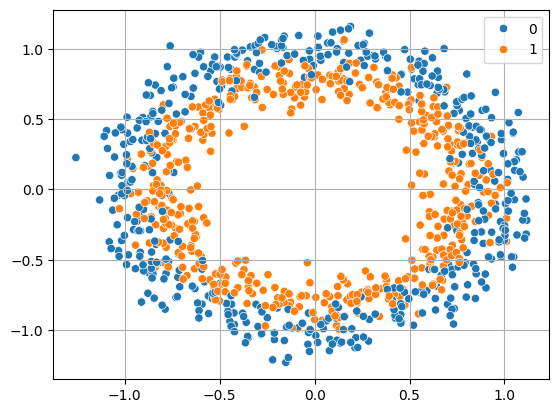

In [16]:
sns.scatterplot(x = X[: , 0] , y = X[: , 1] , hue = y)
plt.grid()
plt.show()


In [17]:
import random


X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state = 42)


In [20]:
model = Sequential()


model.add(Dense(128 , activation = 'relu' , input_shape = (2,)))
model.add(Dense(128 , activation = 'relu'))
model.add(Dense(1 , activation = 'sigmoid'))


In [22]:
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [27]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=35, verbose=1)

Epoch 1/35
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8579 - loss: 0.3167 - val_accuracy: 0.7150 - val_loss: 0.6115
Epoch 2/35
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8649 - loss: 0.3105 - val_accuracy: 0.7250 - val_loss: 0.5940
Epoch 3/35
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8515 - loss: 0.3182 - val_accuracy: 0.7200 - val_loss: 0.6109
Epoch 4/35
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8544 - loss: 0.3251 - val_accuracy: 0.7200 - val_loss: 0.6078
Epoch 5/35
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8788 - loss: 0.2906 - val_accuracy: 0.7050 - val_loss: 0.6084
Epoch 6/35
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8375 - loss: 0.3407 - val_accuracy: 0.7150 - val_loss: 0.6001
Epoch 7/35
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8789 - loss: 0.2936 - val_accuracy: 0.7250 - val_loss: 0.5994
Epoch 8/35
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8769 - loss: 0.3017 - val_accuracy: 0.7250 - val_loss:

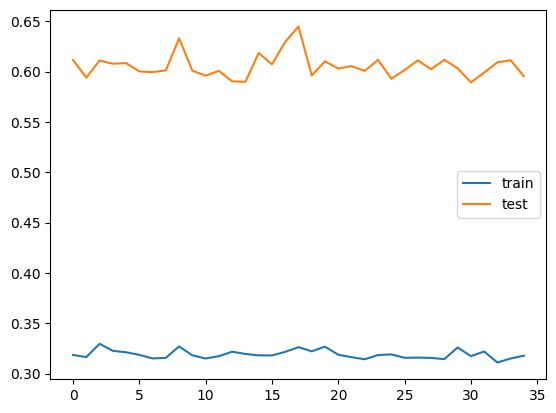

In [28]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


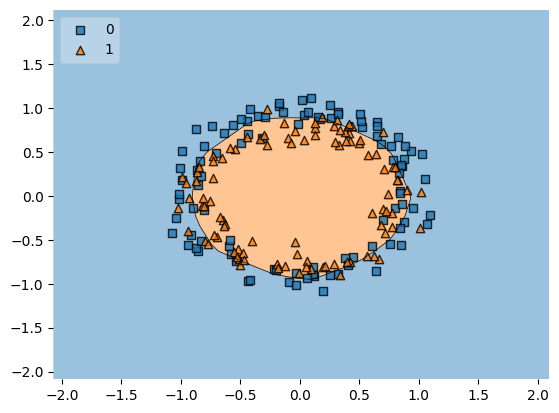

In [29]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

### Early stopping 

In [30]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [32]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [33]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, callbacks=callback)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5194 - loss: 0.6930 - val_accuracy: 0.5050 - val_loss: 0.6905
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5012 - loss: 0.6869 - val_accuracy: 0.5000 - val_loss: 0.6894
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5240 - loss: 0.6788 - val_accuracy: 0.5150 - val_loss: 0.6869
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5334 - loss: 0.6793 - val_accuracy: 0.5850 - val_loss: 0.6846
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5633 - loss: 0.6759 - val_accuracy: 0.5350 - val_loss: 0.6819
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5694 - loss: 0.6717 - val_accuracy: 0.6000 - val_loss: 0.6788
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6402 - loss: 0.6622 - val_accuracy: 0.5850 - val_loss: 0.6751
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6449 - loss: 0.6568 - val_accuracy: 0.6400 - val_loss

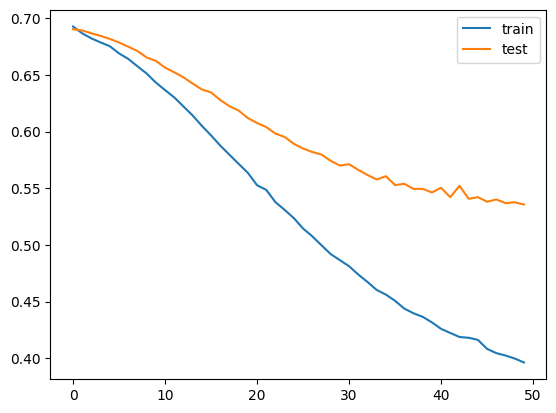

In [34]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


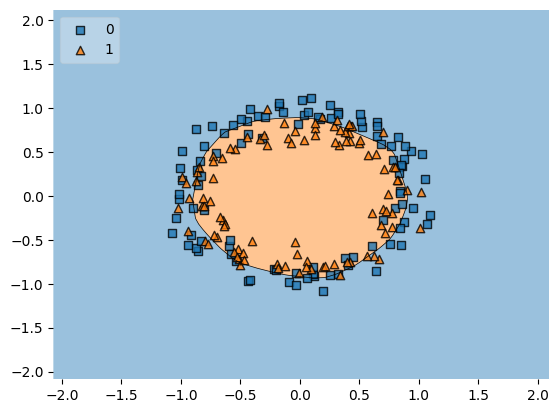

In [35]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()